# Logika i Wnioskowanie rozmyte
### Zastosowanie logiki rozmytej w sterowaniu układem chłodzenia procesora
---
Opracowanie: `Kajetan Kowalski 421071`, IAD III rok, grupa ćwiczeniowa 1.

## 1. Wczytanie bibliotek

In [1]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz 
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

## 2. Wczytanie i preprocessing danych pomiarowych stockowego chłodzenia

In [2]:
data_stock = pd.read_csv("../data/temperatury_stock_v2.csv")
CPU_COL = "T_CPU"
CASE_COL = "T_CASE"
AMBIENT_COL = "T_AMBIENT"
TIME_COL = "time_s"
data_stock["noise"] = (
    data_stock["noise"]
    .rolling(window=15, min_periods=1, center=True)
    .median()
)
display(data_stock)

,timestamp,time_s,T_CPU,T_CASE,T_AMBIENT,amplitude,noise
0,2026-05-11T14:14:28,1.94,34.69,25.62,25.31,318.0,55.5
1,2026-05-11T14:14:29,3.19,34.69,25.62,25.31,287.0,55.0
2,2026-05-11T14:14:31,4.44,34.69,25.62,25.31,311.0,55.0
3,2026-05-11T14:14:32,5.69,34.69,25.62,25.31,329.0,55.0
4,2026-05-11T14:14:33,6.95,34.69,25.62,25.31,298.0,55.0
...,...,...,...,...,...,...,...
3375,2026-05-11T15:24:53,4226.61,37.00,28.31,25.87,299.0,56.5
3376,2026-05-11T15:24:54,4227.87,37.00,28.31,25.94,322.0,56.0
3377,2026-05-11T15:24:55,4229.12,37.00,28.31,25.87,315.0,56.0
3378,2026-05-11T15:24:57,4230.37,37.00,28.31,25.94,332.0,56.0


## 3. Definicja zmiennych rozmytych

#### 3.1. Definicja wszystkich parametrów branych pod uwagę

In [3]:
t_cpu = ctrl.Antecedent(np.arange(25, 61, 0.1), "t_cpu")
t_ambient = ctrl.Antecedent(np.arange(16, 31, 0.1), "t_ambient")
noise = ctrl.Antecedent(np.arange(0, 101, 1), "noise")

pwm = ctrl.Consequent(np.arange(0, 101, 1), "pwm")

#### 3.2. Definicja funkcji przynależności temperatur CPU

In [4]:
t_cpu["niska"] = fuzz.trapmf(t_cpu.universe, [25, 25, 32.5, 35.5])
t_cpu["normalna"] = fuzz.trimf(t_cpu.universe, [33.5, 36.5, 39.5])
t_cpu["wysoka"] = fuzz.trimf(t_cpu.universe, [37.5, 40.5, 44.5])
t_cpu["krytyczna"] = fuzz.trapmf(t_cpu.universe, [43.5, 47.5, 70, 70])

#### 3.3. Definicja funkcji przynależności temperatur otoczenia

In [5]:
t_ambient["chlodno"] = fuzz.trapmf(t_ambient.universe, [16, 16, 20, 22])
t_ambient["normalnie"] = fuzz.trapmf(t_ambient.universe, [21, 22.5, 25.5, 26.5])
t_ambient["cieplo"] = fuzz.trapmf(t_ambient.universe, [25.5, 26.5, 40, 40])

#### 3.4. Definicja funkcji przynależności głośności

In [6]:
noise["cicho"] = fuzz.trapmf(noise.universe, [0, 0, 35, 50])
noise["srednio"] = fuzz.trimf(noise.universe, [45, 60, 75])
noise["glosno"] = fuzz.trapmf(noise.universe, [70, 82, 100, 100])

#### 3.5. Definicja progów zmiennej wyjściowej PWM

In [7]:
pwm["off"] = fuzz.trapmf(pwm.universe, [0, 0, 8, 27])
pwm["low"] = fuzz.trimf(pwm.universe, [22, 42, 58])
pwm["medium"] = fuzz.trimf(pwm.universe, [50, 68, 84])
pwm["high"] = fuzz.trimf(pwm.universe, [72, 88, 98])
pwm["max"] = fuzz.trapmf(pwm.universe, [90, 97, 100, 100])

#### 3.6 Wizualizacja funkcji przynależności 

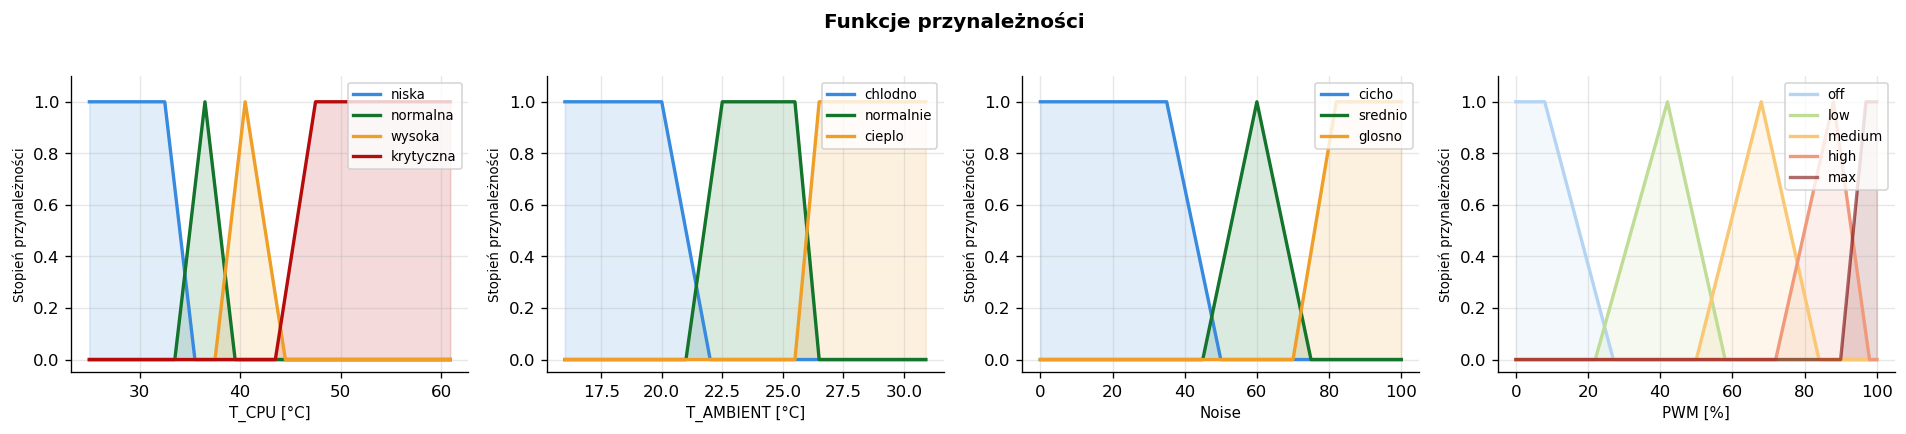

In [8]:
colors = {
    "t_cpu": ["#378ADD", "#13742B", "#EF9F27", "#B60B0B"],
    "t_ambient": ["#378ADD", "#13742B", "#EF9F27"],
    "noise": ["#378ADD", "#13742B", "#EF9F27"],
    "pwm": ["#B5D4F4", "#C0DD97", "#FAC775", "#F0997B", "#77000094"]
}
variables = [
    (t_cpu, "T_CPU [°C]", colors["t_cpu"]),
    (t_ambient, "T_AMBIENT [°C]", colors["t_ambient"]),
    (noise, "Noise", colors["noise"]),
    (pwm, "PWM [%]", colors["pwm"]),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle("Funkcje przynależności", fontsize=12, fontweight="bold", y=1.02)

for ax, (var, xlabel, clrs) in zip(axes, variables):
    for (label, term), color in zip(var.terms.items(), clrs):
        ax.plot(var.universe, term.mf, color=color, linewidth=2, label=label)
        ax.fill_between(var.universe, 0, term.mf, color=color, alpha=0.15)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Stopień przynależności", fontsize=8)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 4. Baza reguł

In [9]:
rule_table = {
    "niska": {
        "chlodno":   {"cicho": "off",    "srednio": "off",    "glosno": "off"},
        "normalnie": {"cicho": "off",    "srednio": "off",    "glosno": "off"},
        "cieplo":    {"cicho": "low",    "srednio": "low",    "glosno": "off"},
    },
    "normalna": {
        "chlodno":   {"cicho": "low",    "srednio": "low",    "glosno": "off"},
        "normalnie": {"cicho": "medium", "srednio": "low",    "glosno": "low"},
        "cieplo":    {"cicho": "medium", "srednio": "medium", "glosno": "low"},
    },
    "wysoka": {
        "chlodno":   {"cicho": "high",   "srednio": "medium", "glosno": "medium"},
        "normalnie": {"cicho": "high",   "srednio": "medium",   "glosno": "medium"},
        "cieplo":    {"cicho": "max",    "srednio": "high",   "glosno": "high"},
    },
    "krytyczna": {
        "chlodno":   {"cicho": "max",    "srednio": "max",    "glosno": "max"},
        "normalnie": {"cicho": "max",    "srednio": "max",    "glosno": "max"},
        "cieplo":    {"cicho": "max",    "srednio": "max",    "glosno": "max"},
    },
}
rules = [
    ctrl.Rule(t_cpu[cpu_l] & t_ambient[amb_l] & noise[noise_l], pwm[pwm_l])
    for cpu_l, ad in rule_table.items()
    for amb_l, nd in ad.items()
    for noise_l, pwm_l in nd.items()
]
fan_ctrl = ctrl.ControlSystem(rules)

print(f"Zbudowano {len(rules)} reguł")

Zbudowano 36 reguł


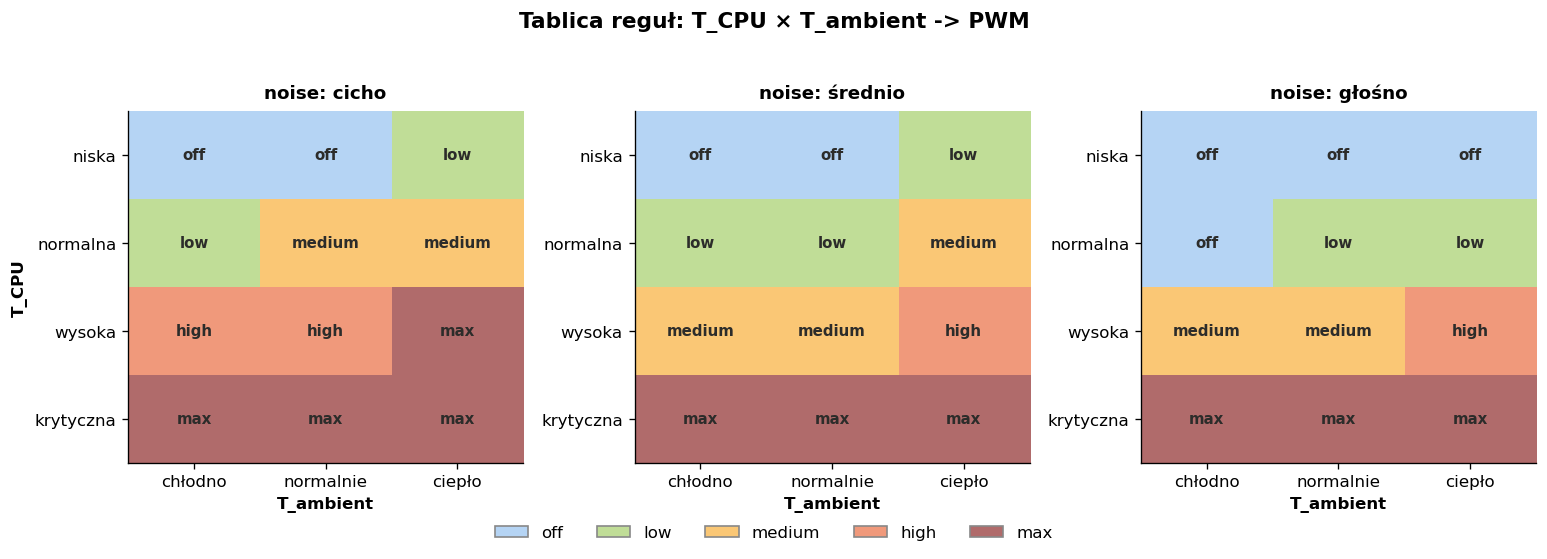

In [10]:
pwm_lvl = ["off", "low", "medium", "high", "max"]
pwm_cols = ["#B5D4F4", "#C0DD97", "#FAC775", "#F0997B", "#77000094"]
pwm_to_idx = {v: i for i, v in enumerate(pwm_lvl)}

cmap_d = mcolors.ListedColormap(pwm_cols)
norm_d = mcolors.BoundaryNorm(np.arange(-0.5, 5), cmap_d.N)

cpu_labels   = ["niska", "normalna", "wysoka", "krytyczna"]
amb_labels   = ["chlodno", "normalnie", "cieplo"]
amb_display  = ["chłodno", "normalnie", "ciepło"]
noise_labels = ["cicho", "srednio", "glosno"]
noise_display = ["cicho", "średnio", "głośno"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
fig.suptitle("Tablica reguł: T_CPU × T_ambient -> PWM", fontsize=13, fontweight="bold", y=1.03)

for ni, (nl, nd) in enumerate(zip(noise_labels, noise_display)):
    ax = axes[ni]
    mx = np.array([[pwm_to_idx[rule_table[cl][al][nl]] for al in amb_labels] for cl in cpu_labels], dtype=float)

    ax.imshow(mx, cmap=cmap_d, norm=norm_d, aspect="auto", origin="upper")
    ax.set_xticks(range(len(amb_labels)))
    ax.set_xticklabels(amb_display, fontsize=10)
    ax.set_yticks(range(len(cpu_labels)))
    ax.set_yticklabels(cpu_labels, fontsize=10)
    ax.set_xlabel("T_ambient", fontsize=10, fontweight="bold")
    ax.set_title(f"noise: {nd}", fontsize=11, fontweight="bold", pad=8)
    ax.grid(False)

    for ci, cl in enumerate(cpu_labels):
        for ai, al in enumerate(amb_labels):
            val = rule_table[cl][al][nl]
            ax.text(ai, ci, val, ha="center", va="center",
                    fontsize=9, fontweight="bold", color="#2C2C2A")

axes[0].set_ylabel("T_CPU", fontsize=10, fontweight="bold")

legend_patches = [Patch(facecolor=pwm_cols[i], label=pwm_lvl[i], edgecolor="#888")
                  for i in range(5)]
fig.legend(handles=legend_patches, loc="lower center", ncol=5,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 5. Symulacja na danych pomiarowych stockowego chłodzenia

#### 5.1. Zastosowanie logiki rozmytej to obliczenia PWM

In [11]:
def compute_pwm(cpu_temp, ambient_temp, noise_level=30.0):
    sim = ctrl.ControlSystemSimulation(fan_ctrl)
    sim.input["t_cpu"] = float(cpu_temp)
    sim.input["t_ambient"] = float(ambient_temp)
    sim.input["noise"] = float(noise_level)

    try:
        sim.compute()
        pwm_value = float(sim.output["pwm"])

        if pwm_value < 30.0:
            pwm_value = 0.0

        return pwm_value

    except Exception:
        return np.nan

In [12]:
data_stock["pwm_fuzzy"] = data_stock.apply(lambda r: compute_pwm(r[CPU_COL], r[AMBIENT_COL], r["noise"]), axis=1)

print(f"PWM - min: {data_stock['pwm_fuzzy'].min():.1f}%  " 
      f"max: {data_stock['pwm_fuzzy'].max():.1f}%  "
      f"mean: {data_stock['pwm_fuzzy'].mean():.1f}%")

PWM - min: 0.0%  max: 96.2%  mean: 64.8%


In [13]:
alpha_pwm = 0.25
filtered = []
prev = 0.0

for value in data_stock["pwm_fuzzy"]:
    if np.isnan(value):
        filtered.append(np.nan)
    else:
        prev = alpha_pwm * value + (1.0 - alpha_pwm) * prev
        filtered.append(prev)

data_stock["pwm_fuzzy_filtered"] = filtered

#### 5.2. Wizualizacja symulacji PWM wentylatora


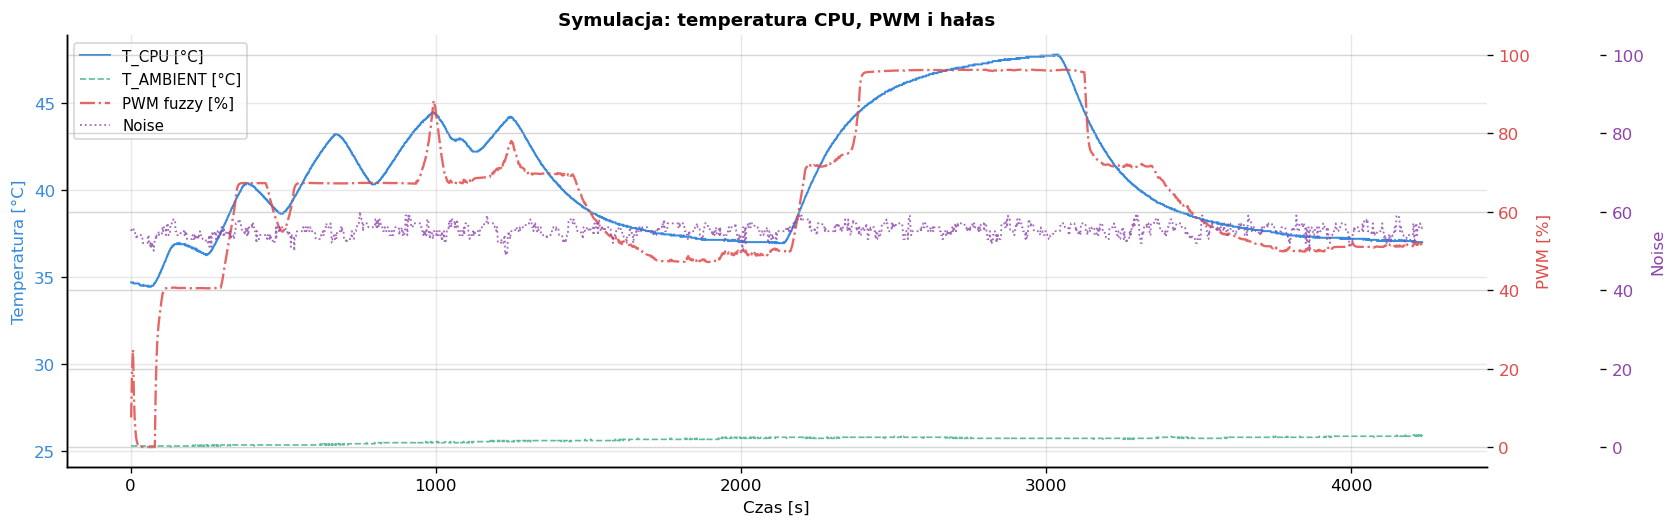

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 4.5))

ax1.plot(data_stock[TIME_COL], data_stock[CPU_COL],
         color="#378ADD", linewidth=1.2, label="T_CPU [°C]")
ax1.plot(data_stock[TIME_COL], data_stock[AMBIENT_COL],
         color="#1D9E75", linewidth=1, linestyle="--", alpha=0.7,
         label="T_AMBIENT [°C]")
ax1.set_xlabel("Czas [s]", fontsize=10)
ax1.set_ylabel("Temperatura [°C]", fontsize=10, color="#378ADD")
ax1.tick_params(axis="y", labelcolor="#378ADD")

ax2 = ax1.twinx()
ax2.plot(data_stock[TIME_COL], data_stock["pwm_fuzzy_filtered"],
         color="#E24B4A", linewidth=1.4, linestyle="-.", alpha=0.85,
         label="PWM fuzzy [%]")
ax2.set_ylabel("PWM [%]", fontsize=10, color="#E24B4A")
ax2.set_ylim(-5, 105)
ax2.tick_params(axis="y", labelcolor="#E24B4A")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.08))
ax3.plot(data_stock[TIME_COL], data_stock["noise"],
         color="#8E44AD", linewidth=1.1, linestyle=":", alpha=0.8,
         label="Noise")
ax3.set_ylabel("Noise", fontsize=10, color="#8E44AD")
ax3.set_ylim(-5, 105)
ax3.tick_params(axis="y", labelcolor="#8E44AD")

lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=9, framealpha=0.8)

plt.title("Symulacja: temperatura CPU, PWM i hałas",
          fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Wizualizacja wnioskowania Mamdaniego

In [15]:
def plot_cpu_fuzzification(cpu_value):
    cpu_colors = ["#378ADD", "#13742B", "#EF9F27", "#B60B0B"]

    def mu(var, label, value):
        return float(fuzz.interp_membership(var.universe, var[label].mf, value))

    cpu_mu = {label: mu(t_cpu, label, cpu_value) for label in t_cpu.terms}

    plt.figure(figsize=(8, 4))

    for (label, term), color in zip(t_cpu.terms.items(), cpu_colors):
        plt.plot(t_cpu.universe, term.mf,
                 color=color, linewidth=2, label=label, alpha=0.75)

    plt.axvline(cpu_value, color="black", linewidth=2,
                linestyle="--", label=f"T_CPU = {cpu_value}°C")

    for label, act in cpu_mu.items():
        if act > 1e-6:
            plt.scatter([cpu_value], [act], color="black", s=60, zorder=5)
            plt.text(cpu_value + 0.3, act, f"{label} = {act:.2f}",
                     fontsize=9)

    plt.xlabel("T_CPU [°C]")
    plt.ylabel("Stopień przynależności")
    plt.ylim(-0.05, 1.1)
    plt.title("Fuzzyfikacja temperatury CPU", fontweight="bold")
    plt.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "zbiór": list(cpu_mu.keys()),
        "stopień_przynależności": list(cpu_mu.values())
    })

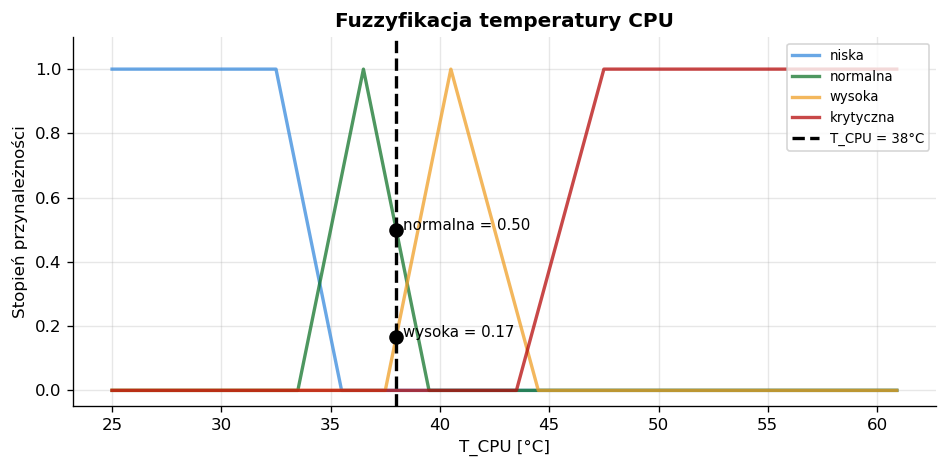

,zbiór,stopień_przynależności
0,niska,0.000000
1,normalna,0.500000
2,wysoka,0.166667
3,krytyczna,0.000000


In [16]:
plot_cpu_fuzzification(38)

In [17]:
def plot_mamdani_inference(cpu_value, ambient_value, noise_value, defuzz_method="centroid"):
    def mu(var, label, value):
        return float(fuzz.interp_membership(var.universe, var[label].mf, value))

    cpu_mu = {l: mu(t_cpu, l, cpu_value) for l in t_cpu.terms}
    amb_mu = {l: mu(t_ambient, l, ambient_value) for l in t_ambient.terms}
    noi_mu = {l: mu(noise, l, noise_value) for l in noise.terms}

    aggregated = np.zeros_like(pwm.universe, dtype=float)
    active_rules = []

    for cpu_l, ad in rule_table.items():
        for amb_l, nd in ad.items():
            for noi_l, pwm_l in nd.items():
                activation = min(cpu_mu[cpu_l], amb_mu[amb_l], noi_mu[noi_l])
                if activation > 1e-6:
                    clipped = np.fmin(activation, pwm[pwm_l].mf)
                    aggregated = np.fmax(aggregated, clipped)
                    active_rules.append({
                        "T_CPU": cpu_l,
                        "T_ambient": amb_l,
                        "noise": noi_l,
                        "PWM": pwm_l,
                        "aktywacja": round(activation, 4)
                    })

    if aggregated.max() < 1e-9:
        print("Żadna reguła nie została aktywowana - nie można defuzyfikować.")
        return pd.DataFrame(active_rules), None

    pwm_result = fuzz.defuzz(pwm.universe, aggregated, defuzz_method)
    pwm_membership = fuzz.interp_membership(pwm.universe, aggregated, pwm_result)

    pwm_colors = ["#B5D4F4", "#C0DD97", "#FAC775", "#F0997B", "#77000094"]

    n_terms = len(pwm.terms)
    assert n_terms == len(pwm_colors), (
        f"Liczba termów PWM ({n_terms}) != liczba kolorów ({len(pwm_colors)})"
    )

    plt.figure(figsize=(10, 4.5))
    for (label, term), color in zip(pwm.terms.items(), pwm_colors):
        plt.plot(pwm.universe, term.mf,
                 color=color, linewidth=2, label=label, alpha=0.7)

    plt.fill_between(pwm.universe, 0, aggregated,
                     color="#888780", alpha=0.35,
                     label="zagregowany wynik")
    plt.axvline(pwm_result, color="#E24B4A", linewidth=2.5, linestyle="--",
                label=f"{defuzz_method} = {pwm_result:.1f}%")
    plt.scatter([pwm_result], [pwm_membership],
                color="#E24B4A", s=80, zorder=5)

    plt.xlabel("PWM wentylatora [%]", fontsize=10)
    plt.ylabel("Stopień przynależności", fontsize=10)
    plt.ylim(-0.05, 1.15)
    plt.title(
        f"Wnioskowanie Mamdaniego i defuzyfikacja\n"
        f"T_CPU={cpu_value}°C | T_AMB={ambient_value}°C | noise={noise_value}",
        fontsize=11, fontweight="bold"
    )
    plt.legend(fontsize=8, loc="upper right", ncol=2)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(active_rules).sort_values(
        "aktywacja", ascending=False
    ).reset_index(drop=True)

    return df, pwm_result

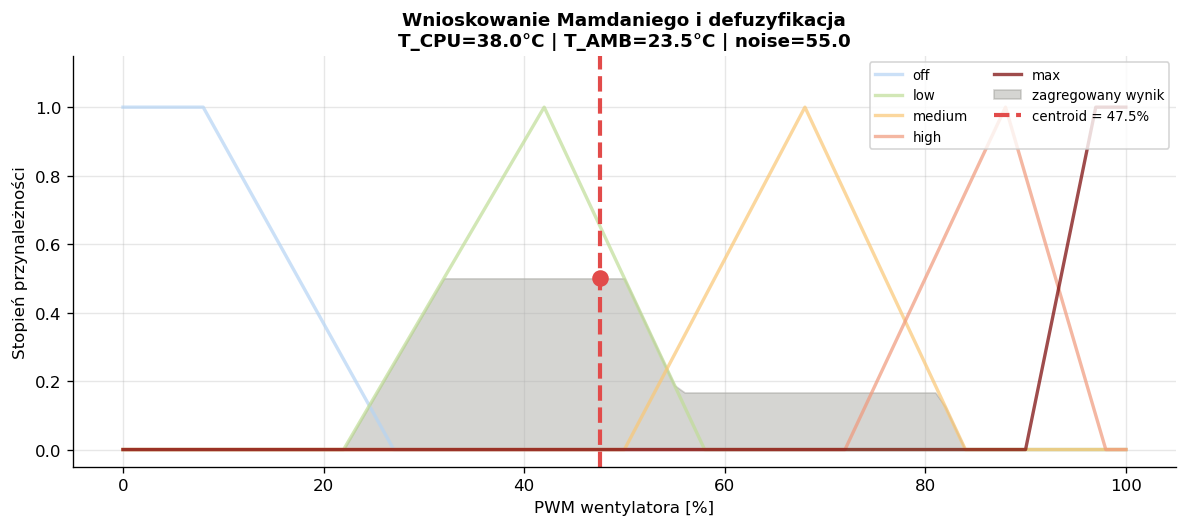


Wartość wyjściowa PWM = 47.54%
Liczba aktywnych reguł: 2



,T_CPU,T_ambient,noise,PWM,aktywacja
0,normalna,normalnie,srednio,low,0.5000
1,wysoka,normalnie,srednio,medium,0.1667


In [18]:
active_rules, pwm_val = plot_mamdani_inference(
    cpu_value=38.0,
    ambient_value=23.5,
    noise_value=55.0,
)

print(f"\nWartość wyjściowa PWM = {pwm_val:.2f}%")
print(f"Liczba aktywnych reguł: {len(active_rules)}\n")
display(active_rules)

## 7. Przestrzeń sterowania - izolinie PWM

In [19]:
cpu_range = np.arange(25, 61, 0.75)
amb_range = np.arange(16, 31, 0.25)
CPU_G, AMB_G = np.meshgrid(cpu_range, amb_range)

NOISE_SLICES = {
    "cicho (15)": 15,
    "średnio (42)": 42,
    "głośno (70)": 70,
}

PWM_GRIDS = {}

for label, nv in NOISE_SLICES.items():
    grid = np.full_like(CPU_G, np.nan, dtype=float)

    for i in range(CPU_G.shape[0]):
        for j in range(CPU_G.shape[1]):
            sim = ctrl.ControlSystemSimulation(fan_ctrl)

            try:
                sim.input["t_cpu"] = CPU_G[i, j]
                sim.input["t_ambient"] = AMB_G[i, j]
                sim.input["noise"] = nv
                sim.compute()
                grid[i, j] = sim.output["pwm"]
            except Exception:
                grid[i, j] = np.nan

    PWM_GRIDS[label] = grid
    print(f"Obliczono siatkę: {label}")

ISO_LEVELS = [5, 15, 25, 35, 50, 65, 78, 90, 98]

DATA_CPU_MIN = data_stock[CPU_COL].min()
DATA_CPU_MAX = data_stock[CPU_COL].max()
DATA_AMB_MIN = data_stock[AMBIENT_COL].min()
DATA_AMB_MAX = data_stock[AMBIENT_COL].max()

Obliczono siatkę: cicho (15)
Obliczono siatkę: średnio (42)
Obliczono siatkę: głośno (70)


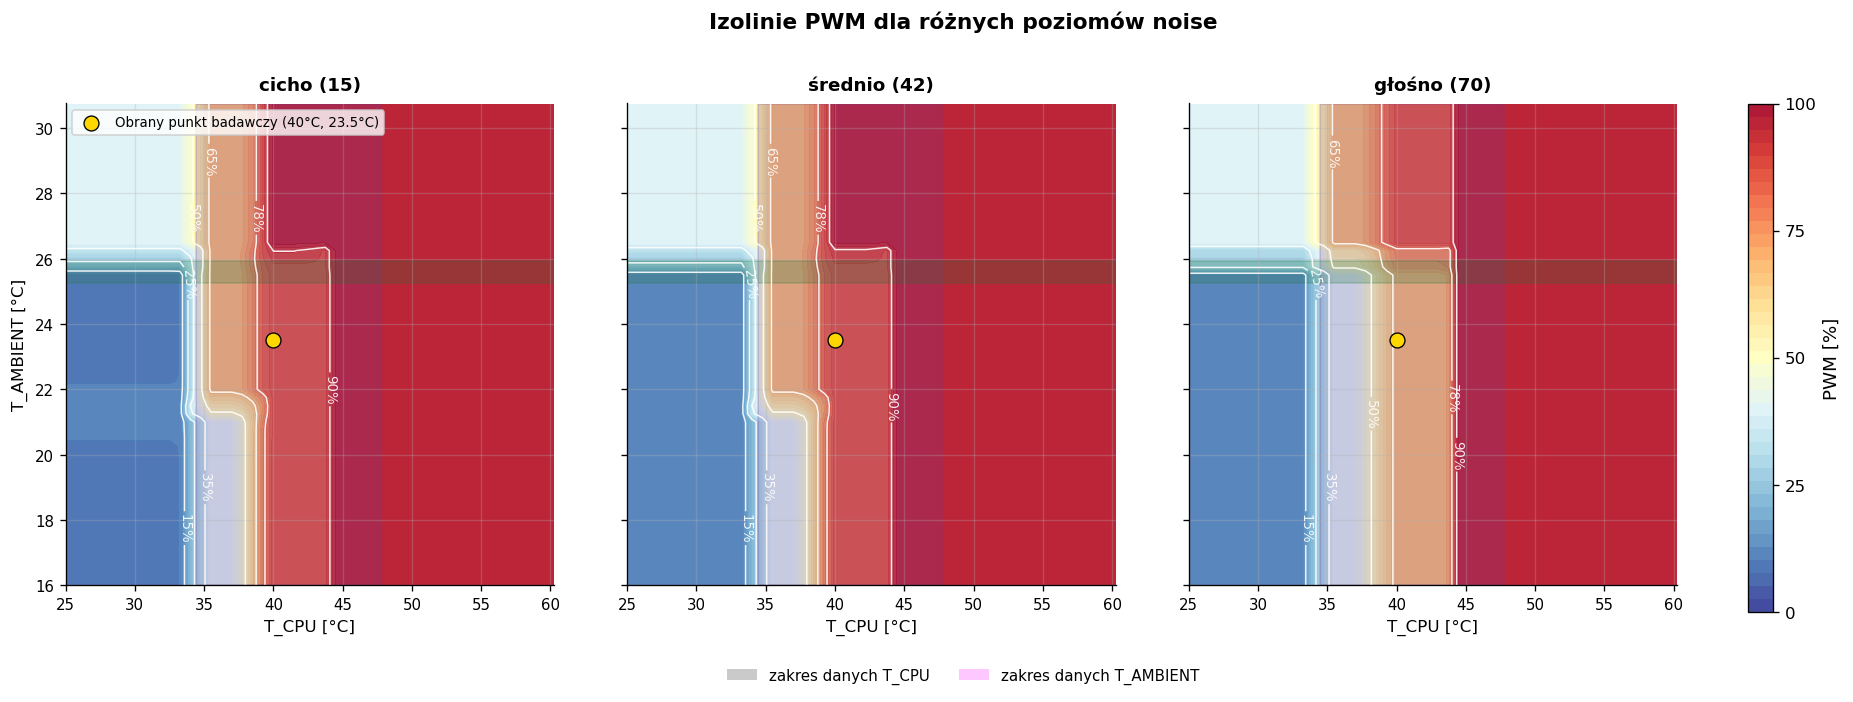

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)

fig.suptitle(
    "Izolinie PWM dla różnych poziomów noise",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

cf_last = None

for ni, (label, grid) in enumerate(PWM_GRIDS.items()):
    ax = axes[ni]

    cf = ax.contourf(
        CPU_G,
        AMB_G,
        grid,
        levels=np.linspace(0, 100, 40),
        cmap="RdYlBu_r",
        alpha=0.92
    )

    cs = ax.contour(
        CPU_G,
        AMB_G,
        grid,
        levels=ISO_LEVELS,
        colors="white",
        linewidths=0.9,
        alpha=0.9
    )

    ax.clabel(cs, fmt="%d%%", fontsize=8, inline=True, inline_spacing=3)

    ax.axvspan(
        DATA_CPU_MIN,
        DATA_CPU_MAX,
        alpha=0.22,
        color="#6A3D9A"
    )

    ax.axhspan(
        DATA_AMB_MIN,
        DATA_AMB_MAX,
        alpha=0.22,
        color="#1B7837"
    )

    ax.scatter(
        [40],
        [23.5],
        color="#FFD700",
        s=80,
        zorder=10,
        edgecolors="black",
        linewidths=0.8,
        label="Obrany punkt badawczy (40°C, 23.5°C)"
    )

    ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("T_CPU [°C]", fontsize=10)

    if ni == 0:
        ax.set_ylabel("T_AMBIENT [°C]", fontsize=10)
        ax.legend(fontsize=8, loc="upper left")

    ax.tick_params(labelsize=9)
    cf_last = cf

cbar = fig.colorbar(
    cf_last,
    ax=axes.ravel().tolist(),
    orientation="vertical",
    fraction=0.02,
    pad=0.06
)

cbar.set_label("PWM [%]", fontsize=11)
cbar.set_ticks([0, 25, 50, 75, 100])


legend_items = [
    Patch(facecolor="#111111", alpha=0.22, label="zakres danych T_CPU"),
    Patch(facecolor="#FF00FF", alpha=0.22, label="zakres danych T_AMBIENT"),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02)
)
plt.subplots_adjust(
    left=0.06,
    right=0.85,
    bottom=0.15,
    top=0.88,
    wspace=0.15
)
plt.show()

# CZESC II

## 1. Wczytanie danych pomiarowych z zaimplementowanego rozwiązania

In [21]:
data_fuzzy = pd.read_csv("../data/temperatury_fuzzy.csv")
data_fuzzy = data_fuzzy.iloc[:,:-3]
display(data_fuzzy)

,timestamp,time_s,T_CPU,T_CASE,T_AMBIENT,noise,pwm
0,2026-05-13T12:36:49,2.05,33.88,31.81,25.56,28.20,0.00
1,2026-05-13T12:36:50,3.41,33.94,31.81,25.62,40.08,7.51
2,2026-05-13T12:36:52,4.82,33.94,31.75,25.56,43.03,13.22
3,2026-05-13T12:36:53,6.25,33.94,31.75,25.62,48.41,19.29
4,2026-05-13T12:36:54,7.66,34.00,31.75,25.56,55.97,14.47
...,...,...,...,...,...,...,...
3002,2026-05-13T13:47:12,4225.40,35.13,33.13,26.69,82.66,51.61
3003,2026-05-13T13:47:14,4226.81,35.13,33.19,26.69,67.86,54.06
3004,2026-05-13T13:47:15,4228.22,35.13,33.13,26.69,51.15,55.76
3005,2026-05-13T13:47:16,4229.62,35.13,33.13,26.75,55.86,57.28


In [22]:
data_pid = pd.read_csv("../data/temperatury_target.csv")
data_pid = data_pid.iloc[:,:-3]
data_pid

,timestamp,time_s,T_CPU,T_CASE,T_AMBIENT,noise,pwm
0,2026-05-13T13:54:42,2.05,34.75,32.44,26.25,36.60,11.75
1,2026-05-13T13:54:43,3.46,34.81,32.44,26.25,36.84,20.86
2,2026-05-13T13:54:45,4.88,34.81,32.44,26.25,41.14,27.69
3,2026-05-13T13:54:46,6.30,34.81,32.44,26.25,48.25,31.48
4,2026-05-13T13:54:47,7.72,34.88,32.38,26.19,55.30,35.75
...,...,...,...,...,...,...,...
3285,2026-05-13T15:05:06,4226.21,36.69,33.13,26.62,44.98,42.18
3286,2026-05-13T15:05:07,4227.49,36.69,33.13,26.62,47.39,42.18
3287,2026-05-13T15:05:08,4228.78,36.69,33.13,26.56,50.16,42.18
3288,2026-05-13T15:05:10,4230.07,36.69,33.13,26.62,54.86,42.18


## 1.1. Weryfikacja danych

In [23]:
raw_stock = data_stock.copy()
raw_fuzzy = data_fuzzy.copy()
raw_pid   = data_pid.copy()

def prep(df, name):
    d = df.copy()
    d["source"] = name
    if "pwm" not in d.columns:
        d["pwm"] = np.nan
    d["noise"] = pd.to_numeric(d["noise"], errors="coerce")
    d["noise_smooth"] = d["noise"].rolling(window=15, min_periods=1, center=True).median()
    d["time_s"] = pd.to_numeric(d["time_s"], errors="coerce")
    return d

data = {
    "stock": prep(raw_stock, "stock"),
    "fuzzy": prep(raw_fuzzy, "fuzzy"),
    "pid":   prep(raw_pid,   "pid"),
}

for name, df in data.items():
    print(f"{name:6s}: {len(df):5d} próbek | "
          f"T_CPU {df['T_CPU'].min():.1f}–{df['T_CPU'].max():.1f}°C | "
          f"czas {df['time_s'].max():.0f}s")

stock :  3380 próbek | T_CPU 34.4–47.8°C | czas 4232s
fuzzy :  3007 próbek | T_CPU 33.9–42.8°C | czas 4231s
pid   :  3290 próbek | T_CPU 34.8–41.4°C | czas 4231s


## 2. Zestawienie temperatur różnych metod chłodzenia

#### 2.1. Temperatury oraz obrane PWM podczas testów

In [24]:
Col2 = {
    "stock":  "#D411AA",
    "fuzzy":  "#378ADD",
    "pid":    "#1D9E75",
    "pwm":    "#E24B4A",
    "noise":  "#8E44AD",
    "ambient":"#EF9F27",
}

In [25]:
configs = [
    ("stock", "Stock (bez sterowania rozmytego)", Col2["stock"]),
    ("fuzzy", "Logika rozmyta", Col2["fuzzy"]),
    ("pid",   "PID - setpoint 36°C", Col2["pid"]),
]

SETPOINT = 36.0
summary_rows = []

for name, title, _ in configs:
    df    = data[name]
    error = df["T_CPU"] - SETPOINT
    row = {
        "Tryb": title,
        "T_CPU śr. [°C]": f"{df['T_CPU'].mean():.2f}",
        "T_CPU std [°C]": f"{df['T_CPU'].std():.2f}",
        "T_CPU min [°C]": f"{df['T_CPU'].min():.2f}",
        "T_CPU max [°C]": f"{df['T_CPU'].max():.2f}",
        "T_CPU p95 [°C]": f"{df['T_CPU'].quantile(0.95):.2f}",
        "T_AMB śr. [°C]": f"{df['T_AMBIENT'].mean():.2f}",
        "Błąd śr. [°C]": f"{error.mean():.2f}",
        "RMSE [°C]": f"{np.sqrt((error**2).mean()):.2f}",
        "±1°C [%próbek]": f"{(error.abs()<=1).mean()*100:.1f}",
        "PWM śr. [%]": f"{df['pwm'].mean():.1f}" if df['pwm'].notna().any() else "—",
        "PWM std [%]": f"{df['pwm'].std():.1f}"  if df['pwm'].notna().any() else "—",
        "Noise śr.": f"{df['noise_smooth'].mean():.1f}",
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("Tryb")
display(summary)

,T_CPU śr. [°C],T_CPU std [°C],T_CPU min [°C],T_CPU max [°C],T_CPU p95 [°C],T_AMB śr. [°C],Błąd śr. [°C],RMSE [°C],±1°C [%próbek],PWM śr. [%],PWM std [%],Noise śr.
Tryb,,,,,,,,,,,,
Stock (bez sterowania rozmytego),40.59,3.62,34.44,47.75,47.38,25.66,4.59,5.85,8.6,—,—,55.3
Logika rozmyta,37.95,2.58,33.88,42.75,42.25,26.45,1.95,3.23,43.1,64.5,14.6,81.5
PID - setpoint 36°C,38.15,1.78,34.75,41.44,41.44,26.57,2.15,2.79,46.6,66.8,27.5,76.2


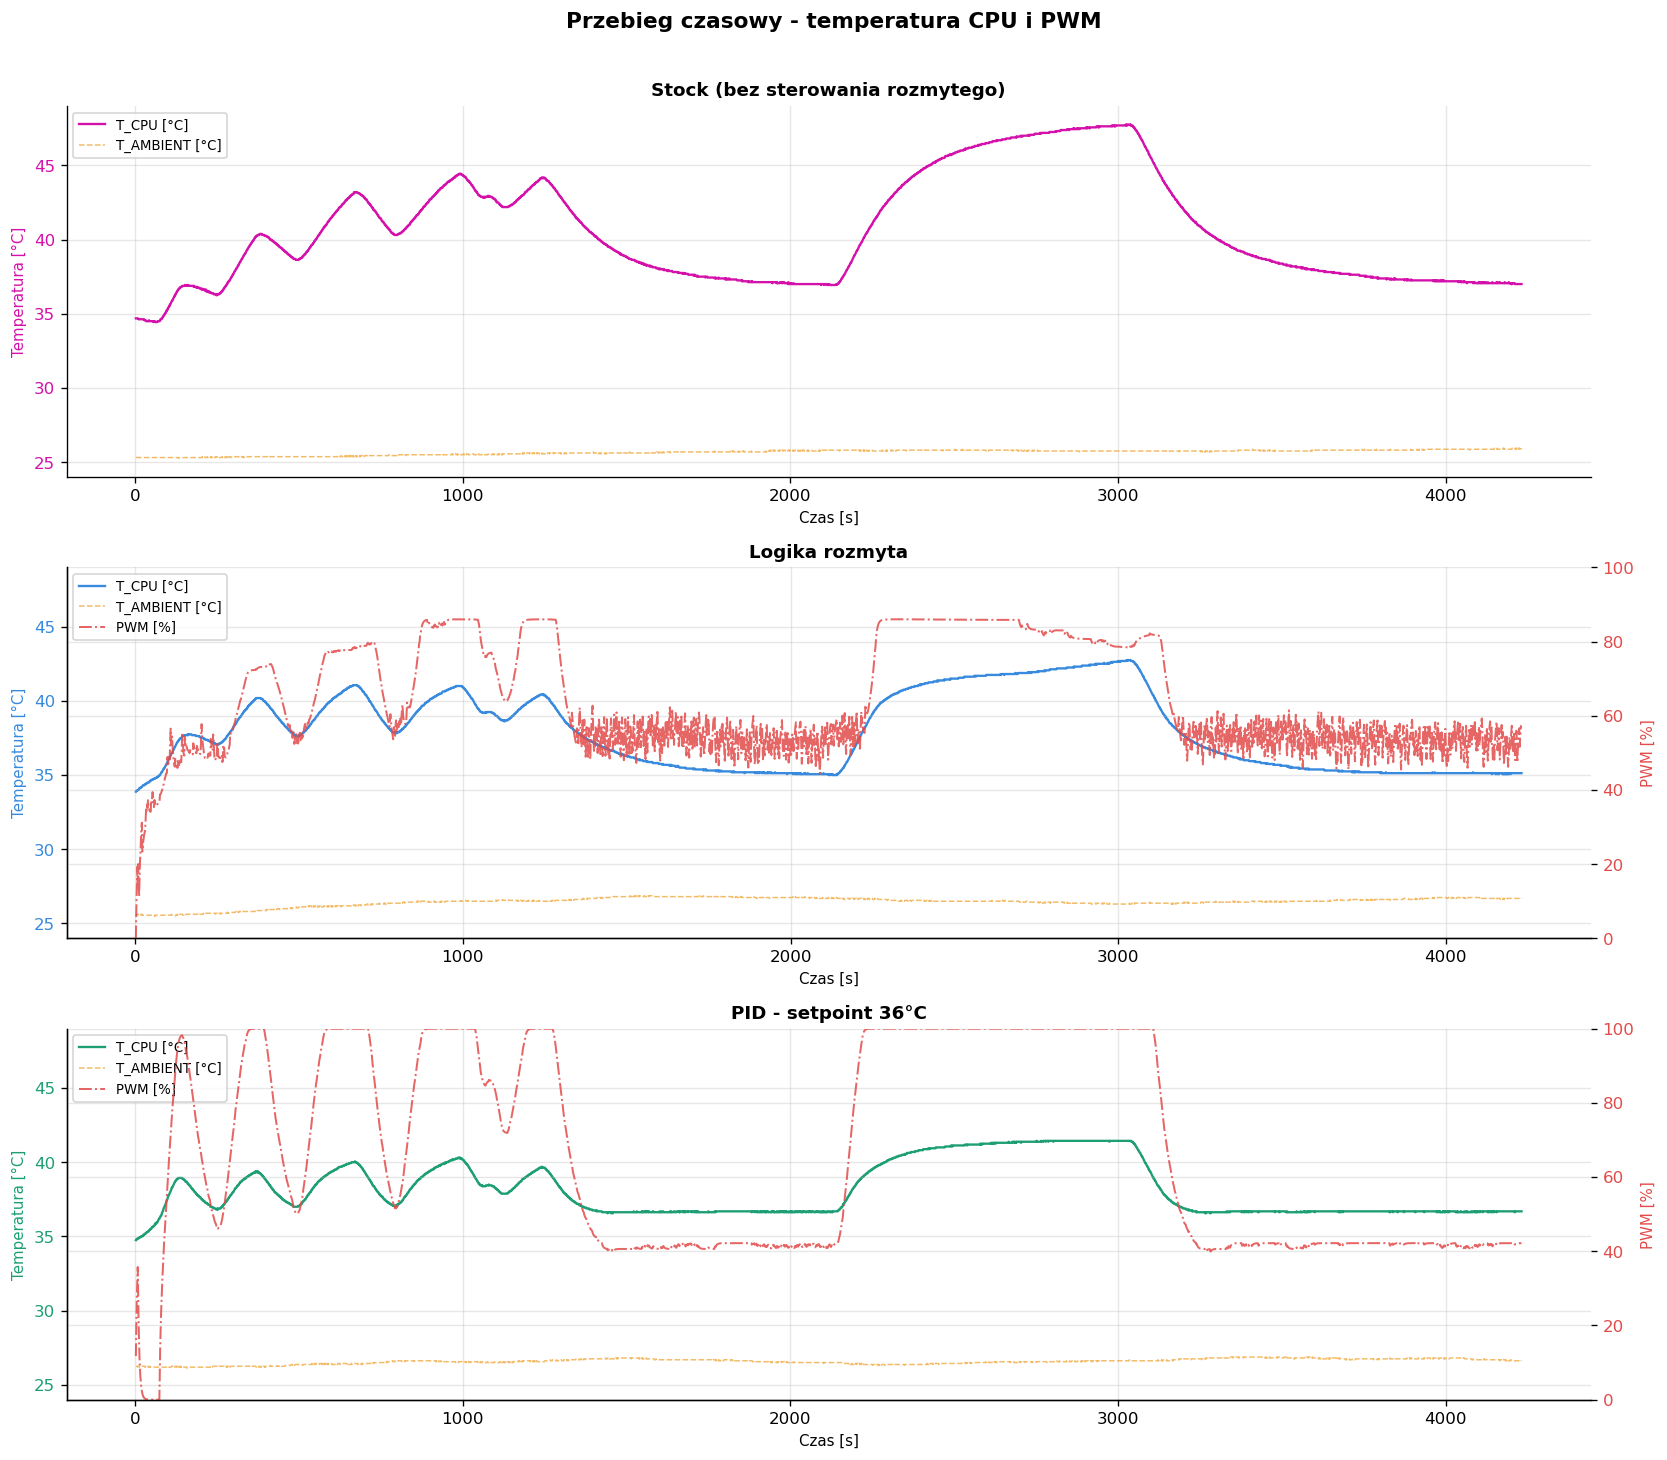

In [26]:
temp_min = min(
    min(df["T_CPU"].min(), df["T_AMBIENT"].min())
    for df in data.values()
)

temp_max = max(
    max(df["T_CPU"].max(), df["T_AMBIENT"].max())
    for df in data.values()
)

y_temp_min = np.floor(temp_min - 1)
y_temp_max = np.ceil(temp_max + 1)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
fig.suptitle(
    "Przebieg czasowy - temperatura CPU i PWM",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

for ax, (name, title, color) in zip(axes, configs):
    df = data[name]
    t = df["time_s"]

    ax.plot(
        t,
        df["T_CPU"],
        color=color,
        linewidth=1.4,
        label="T_CPU [°C]"
    )

    ax.plot(
        t,
        df["T_AMBIENT"],
        color=Col2["ambient"],
        linewidth=0.9,
        linestyle="--",
        alpha=0.7,
        label="T_AMBIENT [°C]"
    )

    ax.set_ylabel("Temperatura [°C]", color=color, fontsize=9)
    ax.tick_params(axis="y", labelcolor=color)
    ax.set_ylim(y_temp_min, y_temp_max)
    ax.set_title(title, fontsize=11, fontweight="bold")

    if df["pwm"].notna().any():
        ax2 = ax.twinx()

        ax2.plot(
            t,
            df["pwm"],
            color=Col2["pwm"],
            linewidth=1.2,
            linestyle="-.",
            alpha=0.85,
            label="PWM [%]"
        )

        ax2.set_ylabel("PWM [%]", color=Col2["pwm"], fontsize=9)
        ax2.set_ylim(0, 100)
        ax2.tick_params(axis="y", labelcolor=Col2["pwm"])

        lines = ax.get_lines() + ax2.get_lines()
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, fontsize=8, loc="upper left")

    else:
        ax.legend(fontsize=8, loc="upper left")

    ax.set_xlabel("Czas [s]", fontsize=9)

plt.tight_layout()
plt.show()

#### 2.2. Zestawienie temperatur 

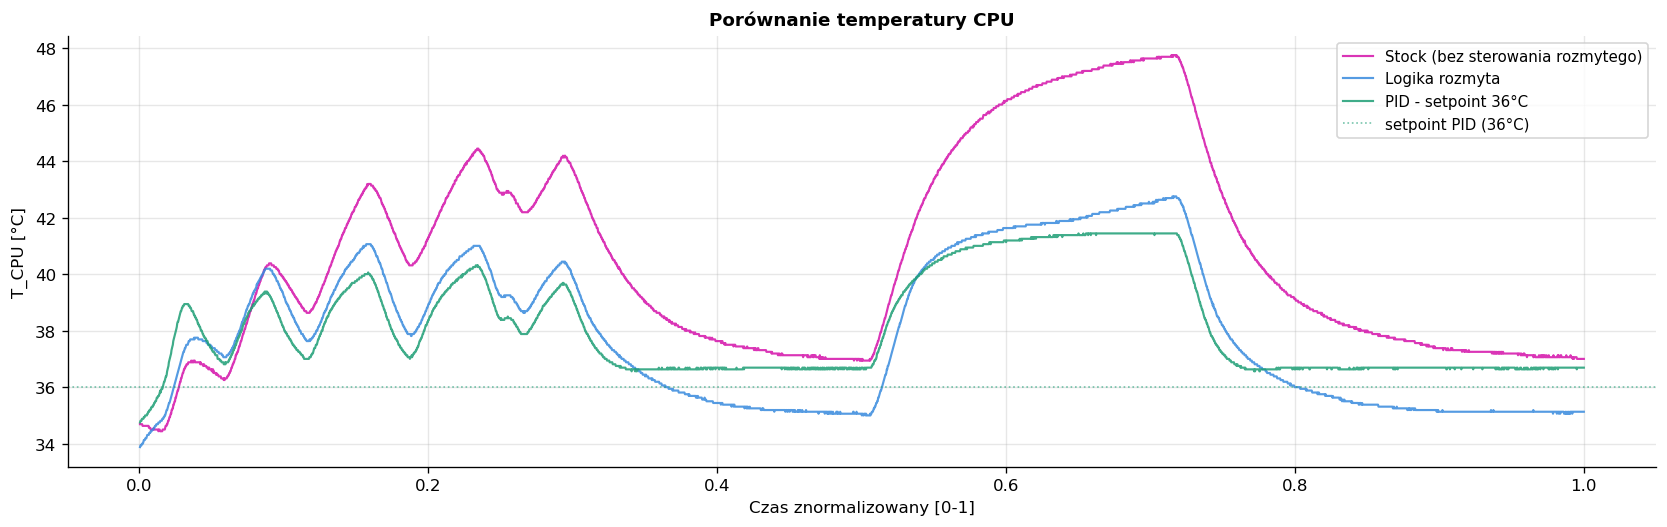

In [27]:
fig, ax = plt.subplots(figsize=(14, 4.5))

for name, title, color in configs:
    df = data[name]
    t_norm = df["time_s"] / df["time_s"].max()
    ax.plot(t_norm, df["T_CPU"], color=color, linewidth=1.3,
            alpha=0.85, label=title)

ax.axhline(36, color=Col2["pid"], linewidth=1, linestyle=":",
           alpha=0.6, label="setpoint PID (36°C)")

ax.set_xlabel("Czas znormalizowany [0-1]", fontsize=10)
ax.set_ylabel("T_CPU [°C]", fontsize=10)
ax.set_title("Porównanie temperatury CPU",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### 3. Analiza rozkładów

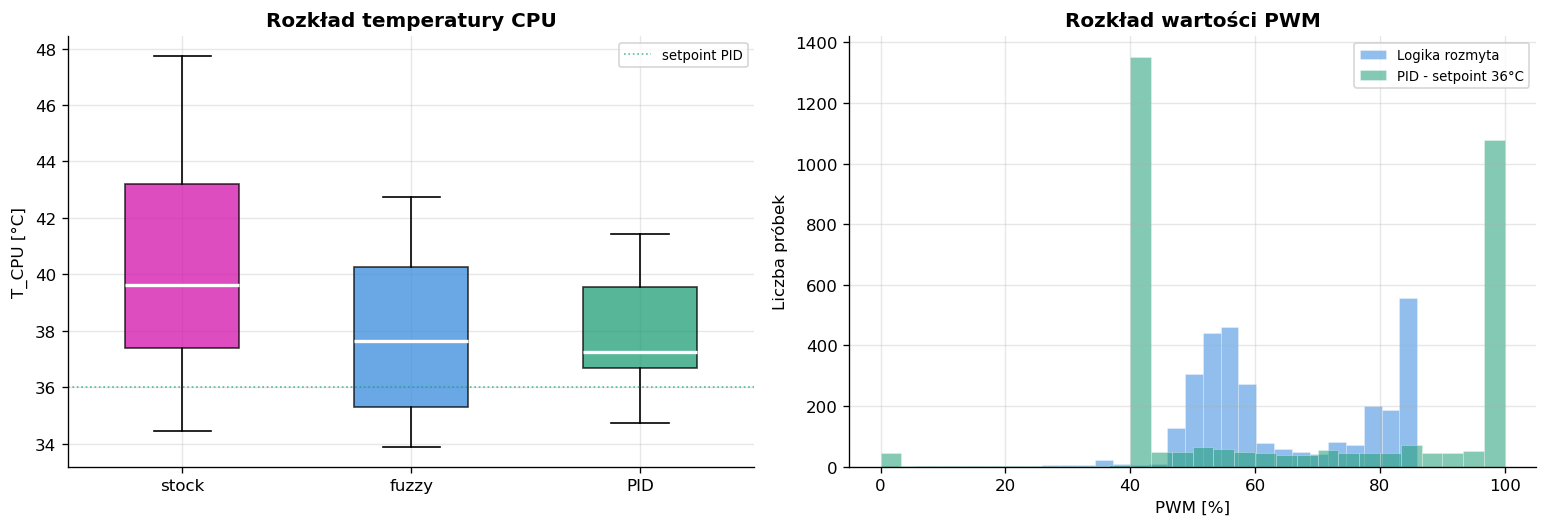

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
bp_data  = [data[n]["T_CPU"].dropna().values for n, *_ in configs]
bp_labels = ["stock", "fuzzy", "PID"]
bp_colors = [Col2["stock"], Col2["fuzzy"], Col2["pid"]]

bp = ax.boxplot(bp_data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(36, color=Col2["pid"], linewidth=1, linestyle=":",
           alpha=0.7, label="setpoint PID")
ax.set_xticklabels(bp_labels)
ax.set_ylabel("T_CPU [°C]")
ax.set_title("Rozkład temperatury CPU", fontweight="bold")
ax.legend(fontsize=8)
ax = axes[1]
for name, title, color in configs:
    df = data[name]
    if df["pwm"].notna().any():
        ax.hist(df["pwm"].dropna(), bins=30, color=color,
                alpha=0.55, label=title, edgecolor="white", linewidth=0.3)

ax.set_xlabel("PWM [%]")
ax.set_ylabel("Liczba próbek")
ax.set_title("Rozkład wartości PWM", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### 4.  Analiza trendu

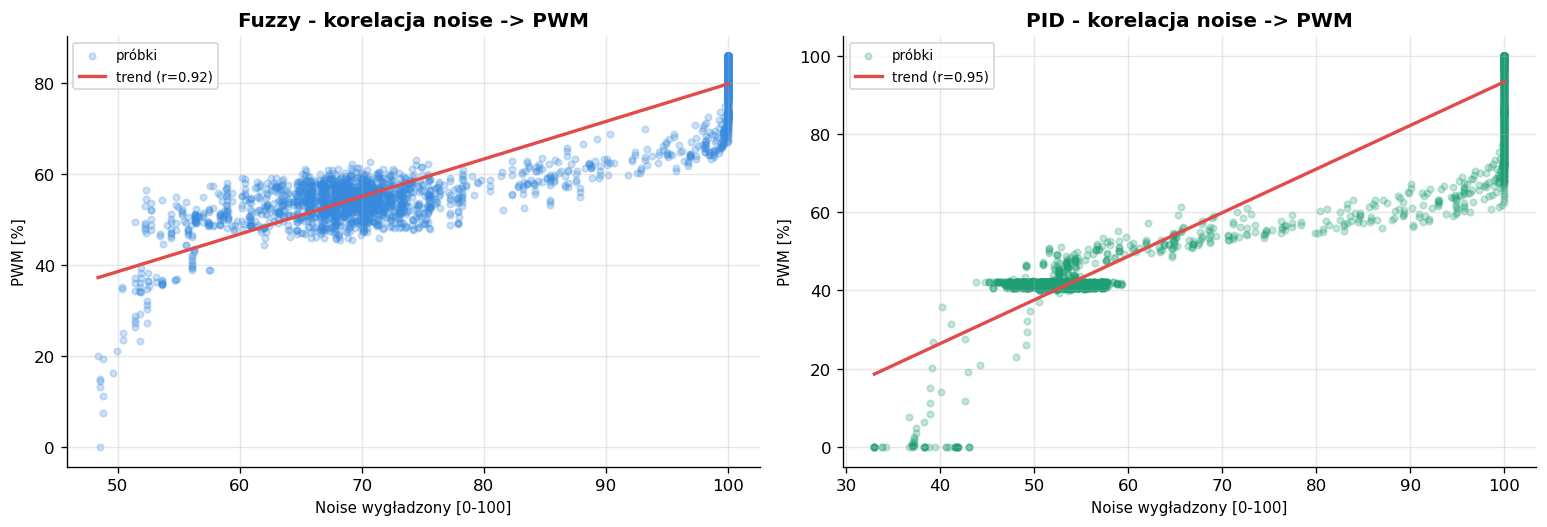

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (name, title, color) in zip(axes, [("fuzzy", "Fuzzy", Col2["fuzzy"]),
                                            ("pid",   "PID",   Col2["pid"])]):
    df = data[name]
    if not df["pwm"].notna().any():
        continue

    x = df["noise_smooth"].dropna()
    y = df["pwm"].loc[x.index]

    ax.scatter(x, y, color=color, alpha=0.25, s=15, label="próbki")

    mask = x.notna() & y.notna()
    if mask.sum() > 5:
        slope, intercept, r, *_ = stats.linregress(x[mask], y[mask])
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, slope * xline + intercept,
                color="#E24B4A", linewidth=2,
                label=f"trend (r={r:.2f})")

    ax.set_xlabel("Noise wygładzony [0-100]", fontsize=9)
    ax.set_ylabel("PWM [%]", fontsize=9)
    ax.set_title(f"{title} - korelacja noise -> PWM", fontweight="bold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### 5. Analiza błędów

Próbek w zakresie ±1°C od setpointu: 46.6%
Błąd średni: 2.153°C  |  RMS: 2.795°C


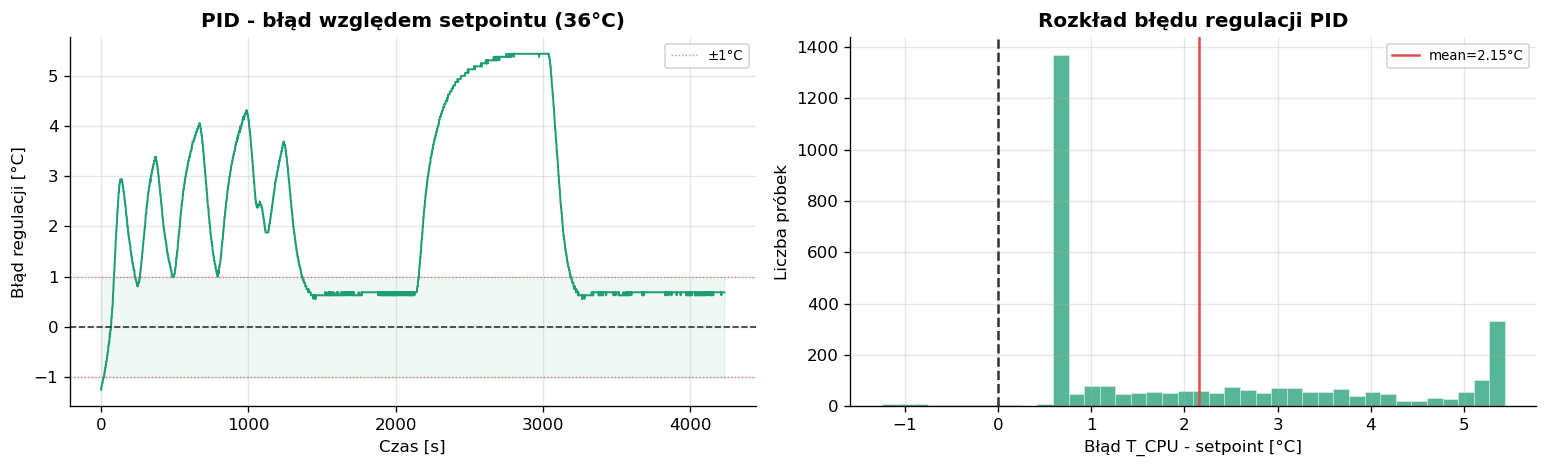

In [30]:
df_pid   = data["pid"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
error = df_pid["T_CPU"] - SETPOINT
ax.plot(df_pid["time_s"], error, color=Col2["pid"], linewidth=1.2)
ax.axhline(0,    color="#333", linewidth=1,   linestyle="--")
ax.axhline( 1.0, color="#E24B4A", linewidth=0.8, linestyle=":", alpha=0.7)
ax.axhline(-1.0, color="#E24B4A", linewidth=0.8, linestyle=":", alpha=0.7,
           label="±1°C")
ax.fill_between(df_pid["time_s"], -1, 1, alpha=0.07, color=Col2["pid"])
ax.set_xlabel("Czas [s]")
ax.set_ylabel("Błąd regulacji [°C]")
ax.set_title("PID - błąd względem setpointu (36°C)", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(error.dropna(), bins=40, color=Col2["pid"], alpha=0.75,
        edgecolor="white", linewidth=0.3)
ax.axvline(0,             color="#333",    linewidth=1.5, linestyle="--")
ax.axvline(error.mean(),  color="#E24B4A", linewidth=1.5, linestyle="-",
           label=f"mean={error.mean():.2f}°C")
ax.set_xlabel("Błąd T_CPU - setpoint [°C]")
ax.set_ylabel("Liczba próbek")
ax.set_title("Rozkład błędu regulacji PID", fontweight="bold")
ax.legend(fontsize=8)

within_1deg = (error.abs() <= 1.0).mean() * 100
print(f"Próbek w zakresie ±1°C od setpointu: {within_1deg:.1f}%")
print(f"Błąd średni: {error.mean():.3f}°C  |  RMS: {np.sqrt((error**2).mean()):.3f}°C")

plt.tight_layout()
plt.show()